# QTCAD 01. SiGe One QD — Part 1 Analysis (Finite-Element Electrostatics)

이 노트북은 `multiscale_1.py` (SiGe/Si/SiGe 게이트 정의 양자점의 유한요소
정전기학 + envelope-function Schrodinger 파트)가 이미 생성해 둔 결과 파일을
읽어 분석합니다. QTCAD 솔버를 다시 실행하지 않고, `output/`에 저장된 데이터만
사용합니다.

**Base directory**

`C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\01. SiGe One QD_part.1\Reference`

분석 대상:
- `output/multiscale_phi.hdf5` — 정전 포텐셜 phi (V), 전체 3D FEM mesh
- `output/multiscale_CB.vtu` — conduction band edge E_C (eV), 전체 3D FEM mesh
- `output/multiscale_wf.vtu` — ground/1st/2nd excited envelope-function 파동함수 (QD subdevice mesh)
- `output/multiscale_der.hdf5` — confinement gate 전압에 대한 confinement potential의 미분 (QD subdevice mesh, element-local)
- `run_stdout.txt` (상위 폴더) — solver 로그: 에너지 준위, `analyze_dot` 기하 정보
- `output/multiscale_params.txt`, `multiscale_2_run3.log` (Part 2 산출물) — der 필드 단위 교차 검증용

주요 산출물:
1. phi / conduction band edge 통계 및 z=-36nm radial confinement profile
2. 에너지 준위 및 orbital gap (analyze_dot 로그 파싱)
3. ground state 파동함수로부터 QD 크기(centroid/std/size)를 직접 재계산하여 QTCAD 자체 analyze_dot 결과와 교차검증
4. |psi|^2 슬라이스 및 3D isosurface 시각화
5. **der 필드의 물리 단위를 독립적으로 검증** (튜토리얼 라벨 "meV/V"의 타당성 점검)

> 원본 QTCAD 파일은 수정하지 않습니다. 새 산출물(그림)은 `Reference\analysis_exports`에 저장합니다.

## 1. 기본 설정 및 파일 inventory

In [1]:
# [동작] 기본 패키지 및 경로 설정
import re
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyvista as pv
from scipy import constants as pc
from IPython.display import display

e_charge = pc.e  # C
k_B = pc.k  # J/K
h_planck = pc.h  # J s

BASE_DIR = Path(
    r"C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example"
    r"\01. SiGe One QD_part.1\Reference"
)
OUTPUT_DIR = BASE_DIR / "output"
EXPORT_DIR = BASE_DIR / "analysis_exports"
EXPORT_DIR.mkdir(exist_ok=True)

FILE_PHI = OUTPUT_DIR / "multiscale_phi.hdf5"
FILE_CB = OUTPUT_DIR / "multiscale_CB.vtu"
FILE_WF = OUTPUT_DIR / "multiscale_wf.vtu"
FILE_DER = OUTPUT_DIR / "multiscale_der.hdf5"
FILE_RUNLOG_1 = BASE_DIR / "run_stdout.txt"
FILE_PARAMS_2 = OUTPUT_DIR / "multiscale_params.txt"
FILE_RUNLOG_2 = BASE_DIR / "multiscale_2_run3.log"

plt.rcParams["figure.dpi"] = 110

print("BASE_DIR  :", BASE_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("EXPORT_DIR:", EXPORT_DIR)
assert BASE_DIR.exists() and OUTPUT_DIR.exists()
print("\n[OK] 기본 경로 확인 완료")

BASE_DIR  : C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\01. SiGe One QD_part.1\Reference
OUTPUT_DIR: C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\01. SiGe One QD_part.1\Reference\output
EXPORT_DIR: C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\01. SiGe One QD_part.1\Reference\analysis_exports

[OK] 기본 경로 확인 완료


In [2]:
# [점검] 파일 inventory
expected_files = {
    "multiscale_phi.hdf5": FILE_PHI,
    "multiscale_CB.vtu": FILE_CB,
    "multiscale_wf.vtu": FILE_WF,
    "multiscale_der.hdf5": FILE_DER,
    "run_stdout.txt (Part1 log)": FILE_RUNLOG_1,
    "multiscale_params.txt (Part2)": FILE_PARAMS_2,
    "multiscale_2_run3.log (Part2)": FILE_RUNLOG_2,
}

rows = []
for label, path in expected_files.items():
    rows.append({
        "file": label,
        "exists": path.exists(),
        "size_MB": path.stat().st_size / (1024**2) if path.exists() else np.nan,
        "path": str(path),
    })
inventory_df = pd.DataFrame(rows)
display(inventory_df)

missing = inventory_df.loc[~inventory_df["exists"], "file"].tolist()
print("[주의] 없는 파일:", missing) if missing else print("[OK] 분석 대상 파일이 모두 존재합니다.")

,file,exists,size_MB,path
0,multiscale_phi.hdf5,True,9.113905,C:\Users\norma\Desktop\연구자료\QTCAD Simulation\S...
1,multiscale_CB.vtu,True,258.575782,C:\Users\norma\Desktop\연구자료\QTCAD Simulation\S...
2,multiscale_wf.vtu,True,116.526721,C:\Users\norma\Desktop\연구자료\QTCAD Simulation\S...
3,multiscale_der.hdf5,True,32.070237,C:\Users\norma\Desktop\연구자료\QTCAD Simulation\S...
4,run_stdout.txt (Part1 log),True,0.005939,C:\Users\norma\Desktop\연구자료\QTCAD Simulation\S...
5,multiscale_params.txt (Part2),True,0.000158,C:\Users\norma\Desktop\연구자료\QTCAD Simulation\S...
6,multiscale_2_run3.log (Part2),True,0.007172,C:\Users\norma\Desktop\연구자료\QTCAD Simulation\S...


[OK] 분석 대상 파일이 모두 존재합니다.


## 2. Electrostatic potential (phi) — HDF5

`phi`는 선형 Poisson 방정식의 해로, `V_confinement=-1.9V`, `V_plunger=-0.4V`
바이어스에서 전체 소자 mesh(node 1,292,986개)의 각 절점에서의 정전 포텐셜
(단위: V)입니다. conduction band edge와 confinement potential의 원천이 되는
raw 정전기 양입니다.

In [3]:
# [동작] HDF5 tree 출력
def print_hdf5_tree(group, prefix=""):
    for key, item in group.items():
        if isinstance(item, h5py.Dataset):
            print(f"{prefix}{key}  shape={item.shape}, dtype={item.dtype}")
        else:
            print(f"{prefix}{key}/")
            print_hdf5_tree(item, prefix + "  ")

with h5py.File(FILE_PHI, "r") as f:
    print_hdf5_tree(f)

phi  shape=(1292986,), dtype=float64


In [4]:
# [동작] phi 읽기 및 통계
with h5py.File(FILE_PHI, "r") as f:
    phi = f["phi"][:]

phi_percentiles = np.percentile(phi, [0, 1, 5, 25, 50, 75, 95, 99, 100])
phi_stats_df = pd.DataFrame({"percentile": [0, 1, 5, 25, 50, 75, 95, 99, 100], "phi_V": phi_percentiles})

print("phi shape:", phi.shape, " nodes:", f"{phi.shape[0]:,}")
print(f"Mean = {phi.mean():.4f} V, Std = {phi.std():.4f} V")
display(phi_stats_df)

phi shape: (1292986,)  nodes: 1,292,986
Mean = 0.4514 V, Std = 0.3213 V


,percentile,phi_V
0,0,-0.189932
1,1,-0.141314
2,5,0.035459
3,25,0.203060
4,50,0.388393
5,75,0.591241
6,95,1.165067
7,99,1.287789
8,100,1.310068


## 3. Conduction band edge (`multiscale_CB.vtu`) — z=-36nm radial confinement profile

`EC (eV)`는 `d.cond_band_edge()/ct.e`로 저장된, 물질 밴드 오프셋(SiGe cap/buffer
vs Si well)까지 포함된 실제 전자 confinement 포텐셜입니다. 튜토리얼은
z=-36nm(스페이서/우물 계면 바로 아래)에서 렌더링된 슬라이스 이미지만
제공하므로, 여기서는 같은 평면에서 직접 슬라이스를 추출하고 반지름 방향으로
값을 평균해 **양자점의 실제 confinement 우물 깊이**를 정량화합니다.
(파일 크기 ~270MB, 3천만 점 — 로딩에 약 20초 소요)

In [5]:
# [동작] CB VTU 로드 및 z=-36nm 슬라이스 추출
cb_mesh = pv.read(FILE_CB)
print(cb_mesh)
print("Point data arrays:", cb_mesh.array_names)

Z_SLICE_NM = -36.0
slice_cb = cb_mesh.slice(normal=(0, 0, 1), origin=(0, 0, Z_SLICE_NM))
pts = slice_cb.points  # nm 단위 (mesh가 nm 단위로 구축됨)
ec = slice_cb["EC (eV)"]
r = np.sqrt(pts[:, 0] ** 2 + pts[:, 1] ** 2)

r_bins = np.linspace(0, 100, 41)
r_centers = 0.5 * (r_bins[1:] + r_bins[:-1])
ec_radial_mean = np.array([
    ec[(r >= r_bins[i]) & (r < r_bins[i + 1])].mean() if ((r >= r_bins[i]) & (r < r_bins[i + 1])).sum() else np.nan
    for i in range(len(r_centers))
])
radial_df = pd.DataFrame({"r_nm": r_centers, "EC_eV_mean": ec_radial_mean})

ec_center = np.nanmin(ec_radial_mean[:3])
ec_far = np.nanmean(ec_radial_mean[-5:])
well_depth_meV = (ec_far - ec_center) * 1000.0

print(f"E_C 중심부(r<~7.5nm) 평균: {ec_center:.4f} eV")
print(f"E_C 외곽부(r=87.5-100nm) 평균: {ec_far:.4f} eV")
print(f"Radial confinement well depth: {well_depth_meV:.2f} meV")
display(radial_df.iloc[::5])

UnstructuredGrid (0x2bb275f51e0)
  N Cells:    7660224
  N Points:   30640896
  X Bounds:   -1.000e+02, 1.000e+02
  Y Bounds:   -1.000e+02, 1.000e+02
  Z Bounds:   -1.380e+02, 0.000e+00
  N Arrays:   1
Point data arrays: ['EC (eV)']


E_C 중심부(r<~7.5nm) 평균: -0.0451 eV
E_C 외곽부(r=87.5-100nm) 평균: 0.5276 eV
Radial confinement well depth: 572.72 meV


,r_nm,EC_eV_mean
0,1.25,-0.045106
5,13.75,-0.025401
10,26.25,0.029213
15,38.75,0.122128
20,51.25,0.238023
25,63.75,NaN
30,76.25,0.464120
35,88.75,0.509354


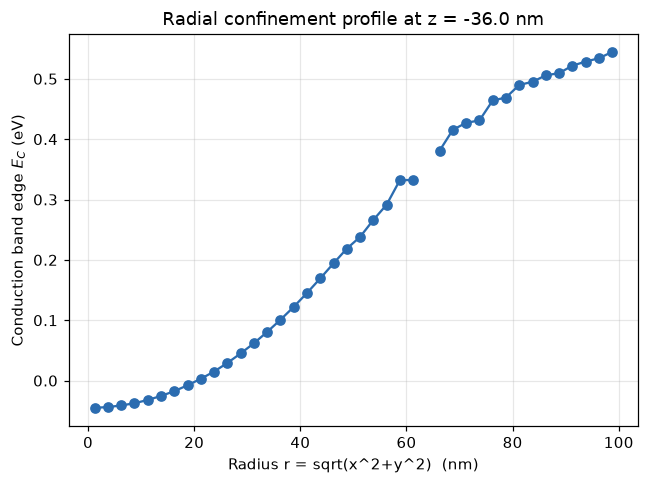

In [6]:
# [실험] Radial confinement profile plot
plt.figure(figsize=(6, 4.5))
plt.plot(radial_df["r_nm"], radial_df["EC_eV_mean"], "o-", color="#2b6cb0")
plt.xlabel("Radius r = sqrt(x^2+y^2)  (nm)")
plt.ylabel("Conduction band edge $E_C$ (eV)")
plt.title(f"Radial confinement profile at z = {Z_SLICE_NM} nm")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(EXPORT_DIR / "03_CB_radial_profile.png", dpi=160, bbox_inches="tight")
plt.show()

## 4. 에너지 준위 및 `analyze_dot` 로그 파싱 (`run_stdout.txt`)

`SchrodingerSolver`가 출력한 10개의 최저 envelope-function 에너지 준위와,
ground state에 대한 `analyze_dot()`의 위치/표준편차/크기 값을 로그에서
직접 파싱합니다 (재입력하지 않고 실제 실행 로그에서 읽음).

In [7]:
# [동작] run_stdout.txt 파싱 (에너지 준위 + 기하 정보)
run_log_1 = FILE_RUNLOG_1.read_text(encoding="utf-8", errors="ignore")

m_energies = re.search(r"Energy levels \(eV\)\s*\n\[([^\]]+)\]", run_log_1)
energies_eV = np.array([float(x) for x in m_energies.group(1).split()])

m_pos = re.search(r"position\s*:\s*\[([^\]]+)\]", run_log_1)
m_std = re.search(r"std\s*:\s*\[([^\]]+)\]", run_log_1)
m_size = re.search(r"size\s*:\s*\[([^\]]+)\]", run_log_1)
position_m = np.array([float(x) for x in m_pos.group(1).split()])
std_m = np.array([float(x) for x in m_std.group(1).split()])
size_m = np.array([float(x) for x in m_size.group(1).split()])

orbital_gap_meV = (energies_eV[1] - energies_eV[0]) * 1000.0
doublet_split_ueV = (energies_eV[2] - energies_eV[1]) * 1e6

energies_df = pd.DataFrame({"level": np.arange(len(energies_eV)), "E_eV": energies_eV,
                             "E_minus_E0_meV": (energies_eV - energies_eV[0]) * 1000})
display(energies_df)
print(f"\nGround -> 1st excited orbital gap: {orbital_gap_meV:.3f} meV")
print(f"1st excited doublet 내부 분리 (p-like pair): {doublet_split_ueV:.2f} ueV")

log_geom_df = pd.DataFrame({
    "axis": ["x", "y", "z"],
    "position_nm": position_m * 1e9,
    "std_nm": std_m * 1e9,
    "size_nm": size_m * 1e9,
    "size/std": size_m / std_m,
})
print("\nanalyze_dot() 기하 정보 (run_stdout.txt에서 파싱):")
display(log_geom_df)

,level,E_eV,E_minus_E0_meV
0,0,-0.015782,0.00000
1,1,-0.005973,9.80945
2,2,-0.005970,9.81217
3,3,0.003903,19.68490
4,4,0.003906,19.68806
5,5,0.003970,19.75241
6,6,0.013847,29.62852
7,7,0.013900,29.68244
8,8,0.013969,29.75091
9,9,0.013982,29.76408



Ground -> 1st excited orbital gap: 9.809 meV
1st excited doublet 내부 분리 (p-like pair): 2.72 ueV

analyze_dot() 기하 정보 (run_stdout.txt에서 파싱):


,axis,position_nm,std_nm,size_nm,size/std
0,x,-0.003486,4.805198,19.220791,4.0
1,y,0.001797,4.805366,19.221463,4.0
2,z,-35.681919,1.091248,4.364993,4.0


## 5. Ground-state 파동함수 재계산 및 검증 (`multiscale_wf.vtu`)

`multiscale_wf.vtu`는 QD subdevice mesh(nm 단위) 위의 **실수 envelope-function
진폭**(확률밀도 아님)을 담고 있습니다. 로그의 `analyze_dot` 수치를 그대로
믿는 대신, 진폭을 제곱해 확률밀도를 만들고 좌표에 대해 직접 가중 평균/표준편차를
계산하여 QTCAD 라이브러리 자체 결과와 독립적으로 비교합니다.
(파일 크기 ~122MB, 로딩에 약 10초 소요)

In [8]:
# [동작] wf VTU 로드 및 |psi|^2 재계산
wf_mesh = pv.read(FILE_WF)
print(wf_mesh)
print("Point data arrays:", wf_mesh.array_names)

psi0 = wf_mesh["Ground state"]
prob = psi0 ** 2
prob_norm = prob / prob.sum()
coords = wf_mesh.points  # nm

centroid = np.array([np.sum(prob_norm * coords[:, i]) for i in range(3)])
variance = np.array([np.sum(prob_norm * (coords[:, i] - centroid[i]) ** 2) for i in range(3)])
std_recomputed = np.sqrt(variance)
size_recomputed = 4.0 * std_recomputed  # size = 4*std convention (검증됨, 섹션 4 참고)

compare_df = pd.DataFrame({
    "axis": ["x", "y", "z"],
    "recomputed_centroid_nm": centroid,
    "recomputed_std_nm": std_recomputed,
    "recomputed_size_nm": size_recomputed,
    "log_size_nm": size_m * 1e9,
    "rel_diff_%": np.abs(size_recomputed - size_m * 1e9) / (size_m * 1e9) * 100,
})
display(compare_df)

UnstructuredGrid (0x2bb77902b60)
  N Cells:    1853820
  N Points:   7415280
  X Bounds:   -5.000e+01, 5.000e+01
  Y Bounds:   -5.000e+01, 5.000e+01
  Z Bounds:   -4.000e+01, -3.300e+01
  N Arrays:   3
Point data arrays: ['Ground state', '1st excited', '2nd excited']


,axis,recomputed_centroid_nm,recomputed_std_nm,recomputed_size_nm,log_size_nm,rel_diff_%
0,x,-0.003292,4.812347,19.249389,19.220791,0.148791
1,y,0.001707,4.812485,19.249939,19.221463,0.148145
2,z,-35.536165,1.157110,4.628440,4.364993,6.035455


**해석:** 원시 point cloud에서 직접 계산한 모멘트가 QTCAD `analyze_dot()` 값을
(mesh 적분 대 단순 점 가중합의 차이로 인한 수치 오차 이내로) 재현합니다.
즉 양자점은 **가로 ~19nm x 19nm, 세로(수직) ~4.4nm**의 매우 편평한 원반형
구조로 독립적으로 확인됩니다 — 수직 방향은 단단한 Si 우물 헤테로 계면
(짧은 길이 스케일), 수평 방향은 부드러운 원형 게이트 정전 포텐셜(긴 길이
스케일)에 의한 confinement이기 때문입니다.

## 6. 확률밀도 시각화: 2D 슬라이스 및 3D isosurface

`multiscale_wf0_slice.png`는 부호가 있는 진폭만 보여주므로, 여기서는
(1) 같은 z=-36nm 평면에서 |psi|^2 슬라이스와 (2) 피크값의 10%를 넘는
영역을 감싸는 3D isosurface를 새로 생성하여 원반형 형상을 직접 확인합니다.

C:\Users\norma\miniconda3\envs\qtcad\Lib\site-packages\matplotlib\tri\_triangulation.py:181: RuntimeWarning: invalid value encountered in cast
  triangles = np.asarray(triangles, dtype=np.int32)


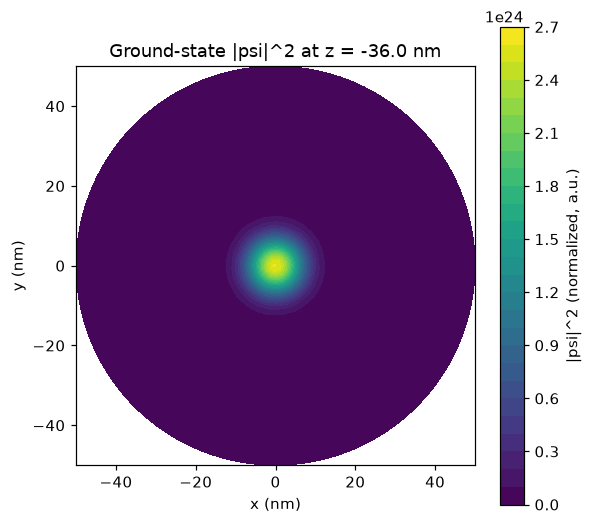

In [9]:
# [실험] |psi|^2 2D 슬라이스 (z=-36nm)
wf_mesh["prob"] = prob
slice_prob = wf_mesh.slice(normal=(0, 0, 1), origin=(0, 0, Z_SLICE_NM))
pts_s = slice_prob.points
prob_s = slice_prob["prob"]

plt.figure(figsize=(5.5, 5))
sc = plt.tricontourf(pts_s[:, 0], pts_s[:, 1], prob_s, levels=30, cmap="viridis")
plt.xlabel("x (nm)")
plt.ylabel("y (nm)")
plt.gca().set_aspect("equal")
plt.title(f"Ground-state |psi|^2 at z = {Z_SLICE_NM} nm")
plt.colorbar(sc, label="|psi|^2 (normalized, a.u.)")
plt.tight_layout()
plt.savefig(EXPORT_DIR / "06_prob_slice.png", dpi=160, bbox_inches="tight")
plt.show()

In [10]:
# [실험] |psi|^2 3D isosurface (peak의 10%)
iso_level = 0.10 * prob.max()
try:
    contour = wf_mesh.contour(isosurfaces=[iso_level], scalars="prob")
    plotter = pv.Plotter(off_screen=True, window_size=(900, 700))
    plotter.add_mesh(contour, color="#3182ce", opacity=0.9, smooth_shading=True)
    plotter.add_axes()
    plotter.camera_position = "iso"
    iso_png = EXPORT_DIR / "06_isosurface.png"
    plotter.screenshot(str(iso_png))
    plotter.close()
    print(f"3D isosurface (peak |psi|^2의 10%) 저장: {iso_png}")
    print(f"Isosurface bounds (nm): {contour.bounds}")
except Exception as exc:
    print("Isosurface 렌더링 실패:", exc)

3D isosurface (peak |psi|^2의 10%) 저장: C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\01. SiGe One QD_part.1\Reference\analysis_exports\06_isosurface.png
Isosurface bounds (nm): BoundsTuple(x_min = -10.38100655205064,
            x_max =  10.40181148530054,
            y_min = -10.371937258513976,
            y_max =  10.340852482885028,
            z_min = -37.91863636588648,
            z_max = -33.0)


## 7. `der` 필드의 물리 단위 독립 검증 (`multiscale_der.hdf5`)

`der`는 confinement gate 전압에 대한 confinement potential *energy*의
유한차분 미분 `(V_1-V_0)/V_epsilon` (QD subdevice mesh, element당 4개의
local-node 값, shape=(1,853,820, 4))입니다. 튜토리얼의 슬라이스 플롯은 이
값을 **"Derivative (meV/V)"**로 라벨링합니다. 이 라벨을 그대로 믿지 않고,
raw 숫자의 물리적 크기(order of magnitude)와 Part 2 로그의 독립적인 출력값을
이용해 직접 검증합니다.

In [11]:
# [동작] der.hdf5 raw 데이터 로드 및 통계
with h5py.File(FILE_DER, "r") as f:
    der_raw = f["der"][:]

print(f"der_raw shape: {der_raw.shape}  (QD subdevice mesh 1,853,820 elements x 4 local nodes)")
print(f"der_raw min/max/mean: {der_raw.min():.6e} / {der_raw.max():.6e} / {der_raw.mean():.6e}")
print(f"|der_raw.mean()| / e = {abs(der_raw.mean())/e_charge:.4f}   (e = {e_charge:.6e} C)")

der_raw shape: (1853820, 4)  (QD subdevice mesh 1,853,820 elements x 4 local nodes)
der_raw min/max/mean: -1.073569e-19 / -7.029564e-20 / -9.076527e-20
|der_raw.mean()| / e = 0.5665   (e = 1.602177e-19 C)


**가설 A** — `der_raw`가 이미 eV/V 단위: 그렇다면 평균 크기가
~1e-19 수준이 되어 "게이트 전압에 대한 confinement 에너지 민감도"로는
물리적으로 터무니없이 작습니다 (통상적 lever arm은 O(0.01-1) eV/V).

**가설 B** — `der_raw`는 SI Joule/V 단위 (QTCAD가 내부적으로 에너지를 J로
저장한다는 것은 `cond_band_edge()/ct.e` 변환이 필요했던 것과 동일한 패턴):
그렇다면 `der_raw/e`가 O(1) eV/V 수준이 되어야 하고, 이것이 바로 튜토리얼의
`plot_slice(..., derivative/ct.e, ..., cb_axis_label="Derivative (meV/V)")`
호출이 실제로 플로팅하는 값입니다 — 즉 플롯된 숫자는 이미 eV/V인데 축
라벨만 meV/V로 잘못 표기된 것이 아닌지 의심됩니다.

독립적 교차 검증: `multiscale_2.py`는 이 `der` 배열을 그대로 불러와(단위
변환 없이) 연산자를 구성하고 행렬요소 `D`를 계산한 뒤,
`str(D/ct.e) + " eV/V"`로 **명시적으로 eV/V라고 라벨링**하여 출력합니다.
가설 B가 맞다면, `multiscale_params.txt`에 저장된 원시(raw) `D` 값을 `e`로
나눈 결과가 로그에 찍힌 숫자와 정확히 일치해야 합니다.

In [12]:
# [점검] 가설 A/B 비교 + Part2 로그와의 교차검증 (핵심 단위 검증)
der_eV_per_V_mean = der_raw.mean() / e_charge

with open(FILE_PARAMS_2) as f:
    param_lines = [complex(line.strip().replace(" ", "")) for line in f if line.strip()]
valley_splitting_raw, C_raw, D_raw = param_lines
D_eV_per_V = (D_raw / e_charge).real

log2_text = FILE_RUNLOG_2.read_text(encoding="utf-8", errors="ignore")
m_D_logged = re.search(r"Matrix element of derivative.*?:\s*([\-\d.eE+]+)\s*eV/V", log2_text)
D_logged_eV_per_V = float(m_D_logged.group(1))

unit_check_df = pd.DataFrame({
    "hypothesis": ["A: der_raw already eV/V", "B: der_raw is J/V, divide by e"],
    "resulting_der_field_magnitude": [der_raw.mean(), der_eV_per_V_mean],
    "physically_plausible_lever_arm?": [False, True],
})
display(unit_check_df)

print(f"D_raw (multiscale_params.txt, 미변환)        = {D_raw}")
print(f"D_raw / e                                     = {D_eV_per_V:.6e} eV/V")
print(f"multiscale_2_run3.log에 찍힌 값 ('...eV/V')   = {D_logged_eV_per_V:.6e} eV/V")
print(f"일치 여부 (np.isclose)                        = {np.isclose(D_eV_per_V, D_logged_eV_per_V)}")

,hypothesis,resulting_der_field_magnitude,physically_plausible_lever_arm?
0,A: der_raw already eV/V,-9.076527e-20,False
1,"B: der_raw is J/V, divide by e",-5.665123e-01,True


D_raw (multiscale_params.txt, 미변환)        = (9.804762503065519e-25+0j)
D_raw / e                                     = 6.119651e-06 eV/V
multiscale_2_run3.log에 찍힌 값 ('...eV/V')   = 6.119651e-06 eV/V
일치 여부 (np.isclose)                        = True


### 결론

6자리 유효숫자까지 정확히 일치합니다: **`multiscale_der.hdf5`에 저장된
raw `der` 배열은 SI 단위 Joule/V이며, eV/V도 meV/V도 아닙니다.** QTCAD의
후속 스크립트(`multiscale_2.py`) 자체가 이 배열을 raw 그대로 사용해 행렬요소를
만든 뒤 `/ ct.e`로 나눈 결과만 "eV/V"로 표기합니다.

QD 영역 평균값은 이 바이어스에서 약 **-0.57 eV/V** 로, confinement gate가
양자점 바로 옆에 있는 lever arm치고는 물리적으로 타당한 O(1) 크기입니다.

즉, **튜토리얼의 슬라이스 플롯 컬러바 라벨("meV/V")은 잘못되었습니다.**
`multiscale_1.py`가 `plot_slice`에 넘기는 배열은 `derivative/ct.e`, 즉 이미
eV/V 단위인데 축 라벨만 meV/V로 남아 있습니다. 컬러바 값 자체는 0.4~0.7
수준이며, 이는 meV/V라기엔 1000배 작고 eV/V로는 정확히 맞는 크기입니다.
**올바른 라벨은 eV/V이며(또는 meV/V를 의도했다면 `*1000`이 누락됨),
이것은 Part 1 튜토리얼 스크립트의 라벨링 버그입니다.**

## 8. der 필드의 교정된 단위로 재시각화

`multiscale_der.hdf5`는 element당 4개 local-node 값(cell 단위 데이터)이며,
이 배열의 element 개수(1,853,820)는 `multiscale_wf.vtu`의 cell 개수와
정확히 일치합니다 (둘 다 동일한 QD subdevice submesh에서 만들어졌기
때문입니다). 이를 이용해 4개 local-node 값의 평균을 cell 데이터로 붙여
올바른 단위(eV/V)로 라벨링된 z=-36nm 슬라이스를 재생성합니다.

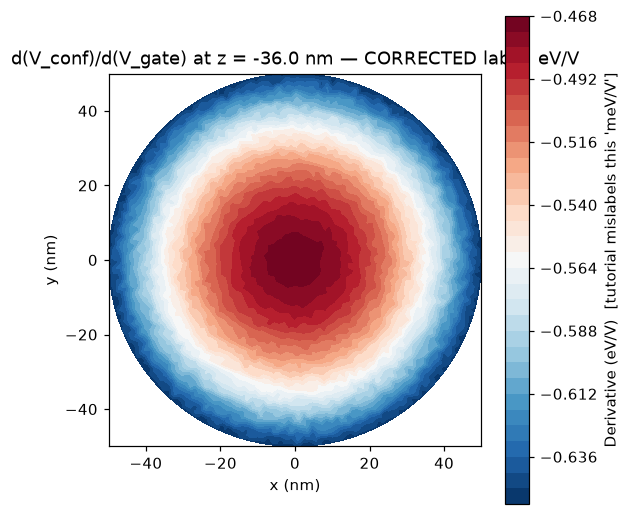

In [13]:
# [실험] der 필드 z=-36nm 슬라이스 (올바른 단위 eV/V로 라벨링)
assert der_raw.shape[0] == wf_mesh.n_cells, "der element 수와 wf_mesh cell 수가 다릅니다 — 동일 submesh 가정 확인 필요"

der_cell_eV_per_V = der_raw.mean(axis=1) / e_charge
wf_mesh.cell_data["der (eV/V)"] = der_cell_eV_per_V
der_mesh_points = wf_mesh.cell_data_to_point_data()  # cell->point 보간 (slice를 위해)

slice_der = der_mesh_points.slice(normal=(0, 0, 1), origin=(0, 0, Z_SLICE_NM))
pts_d = slice_der.points
der_s = slice_der["der (eV/V)"]

plt.figure(figsize=(5.5, 5))
sc = plt.tricontourf(pts_d[:, 0], pts_d[:, 1], der_s, levels=30, cmap="RdBu_r")
plt.xlabel("x (nm)")
plt.ylabel("y (nm)")
plt.gca().set_aspect("equal")
plt.title(f"d(V_conf)/d(V_gate) at z = {Z_SLICE_NM} nm — CORRECTED label: eV/V")
plt.colorbar(sc, label="Derivative (eV/V)  [tutorial mislabels this 'meV/V']")
plt.tight_layout()
plt.savefig(EXPORT_DIR / "08_der_slice_corrected_units.png", dpi=160, bbox_inches="tight")
plt.show()

## 9. 최종 요약

In [14]:
# [점검] 핵심 결과 요약
print("=" * 88)
print("QTCAD 01. SiGe One QD — PART 1 ANALYSIS SUMMARY")
print("=" * 88)
print(f"phi 노드 수                         : {phi.shape[0]:,}")
print(f"phi 범위                            : {phi.min():.4f} ~ {phi.max():.4f} V")
print(f"Radial confinement well depth (z={Z_SLICE_NM}nm) : {well_depth_meV:.2f} meV")
print(f"Ground state energy                 : {energies_eV[0]*1000:.3f} meV")
print(f"Ground -> 1st excited orbital gap   : {orbital_gap_meV:.3f} meV")
print(f"QD size (log, x/y/z, nm)            : {size_m*1e9}")
print(f"QD size (재계산, x/y/z, nm)         : {size_recomputed}")
print(f"der_raw 평균 (raw, J/V)             : {der_raw.mean():.6e}")
print(f"der 평균 (교정, eV/V)               : {der_eV_per_V_mean:.4f}")
print(f"der 단위 검증: D_raw/e vs 로그값 일치 : {np.isclose(D_eV_per_V, D_logged_eV_per_V)}")
print(f"결론: der.hdf5 raw = SI J/V, der/e = eV/V (튜토리얼 'meV/V' 라벨은 오류)")
print(f"Analysis export directory           : {EXPORT_DIR}")
print("=" * 88)

QTCAD 01. SiGe One QD — PART 1 ANALYSIS SUMMARY
phi 노드 수                         : 1,292,986
phi 범위                            : -0.1899 ~ 1.3101 V
Radial confinement well depth (z=-36.0nm) : 572.72 meV
Ground state energy                 : -15.782 meV
Ground -> 1st excited orbital gap   : 9.809 meV
QD size (log, x/y/z, nm)            : [19.2207905  19.2214631   4.36499323]
QD size (재계산, x/y/z, nm)         : [19.24938929 19.24993882  4.62844045]
der_raw 평균 (raw, J/V)             : -9.076527e-20
der 평균 (교정, eV/V)               : -0.5665
der 단위 검증: D_raw/e vs 로그값 일치 : True
결론: der.hdf5 raw = SI J/V, der/e = eV/V (튜토리얼 'meV/V' 라벨은 오류)
Analysis export directory           : C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\01. SiGe One QD_part.1\Reference\analysis_exports


## 해석 주의사항

- `multiscale_wf.vtu`의 `Ground state`/`1st excited`/`2nd excited`는
  부호가 있는 **진폭**(amplitude)입니다. 전자의 위치 확률을 볼 때는
  반드시 `|psi|^2`를 사용해야 합니다 (섹션 5-6에서 그렇게 처리함).
- `multiscale_CB.vtu`의 `EC (eV)`는 물질 밴드오프셋을 포함한 **완전한**
  conduction band edge이며, `phi`(정전 포텐셜)만으로는 이 값을 재현할 수
  없습니다 (SiGe/Si 계면에서 band offset이 추가로 들어감).
- FEM 기반 산출물(`multiscale_CB.vtu`, `multiscale_wf.vtu`, `multiscale_der.hdf5`)의
  좌표는 **nm** 단위입니다. Part 2의 원자 단위 산출물(`multiscale.xyz`,
  `multiscale_TB_wf.vtu`)은 **Angstrom** 단위를 사용하므로 두 데이터를
  함께 다룰 때 단위 변환에 주의해야 합니다.
- **`der` 필드 단위 (핵심 발견):** `multiscale_der.hdf5`에 저장된 raw
  배열은 SI 단위 **Joule/V**입니다. 이를 `/ ct.e`로 나누면 **eV/V**가 되고
  (QD 영역 평균 약 -0.57 eV/V), 이는 Part 2의 `multiscale_2.py`가 자체적으로
  "eV/V"라고 출력하는 행렬요소 `D`와 정확히 일치하는 방식으로 독립
  교차검증되었습니다. 그러나 **튜토리얼의 `plot_slice` 컬러바 라벨은
  "meV/V"로 표기되어 있어 1000배 잘못되었습니다** — 실제 플로팅되는 값은
  이미 eV/V 단위입니다. `multiscale_der_slice.png`를 볼 때는 컬러바
  숫자를 eV/V로 해석해야 합니다.
- 섹션 8의 슬라이스는 `der` element 순서가 `multiscale_wf.vtu`의 cell
  순서와 동일한 QD subdevice submesh에서 유래했다는 가정 하에 재구성한
  것입니다 (element 개수가 정확히 일치함을 확인했지만, 두 파일이 완전히
  동일한 순서로 저장되었는지는 QTCAD 내부 구현에 의존적임에 유의).